EMPLOYEE ATTRITION PREDICTION

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap
import pickle

df = pd.read_csv('IBM-HR-Analytics-Employee-Attrition-and-Performance-Revised.csv')
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome      Education EducationField EnvironmentSatisfaction  \
0                 1        College  Life Sciences                  Medium   
1                 8  Below College  Life Sciences                    High   
2                 2        College          Other               Very High   
3                 3         Master  Life Sciences               Very High   
4                 2  Below College        Medical                     Low   

   Gender  ...  PerformanceRating RelationshipSatisfaction StockOptionLevel  \
0  Female  ..

In [49]:
print('Shape:', df.shape)
df.info()
display(df.describe())

Shape: (1470, 31)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   str  
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   str  
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   str  
 12  JobLevel                  1470 non-null   str  
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 no

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,65.891156,6502.931293,14313.103401,2.693197,15.209524,0.793878,11.279592,2.799320,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,20.329428,4707.956783,7117.786044,2.498009,3.659938,0.852077,7.780782,1.289271,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,30.000000,1009.000000,2094.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,48.000000,2911.000000,8047.000000,1.000000,12.000000,0.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,66.000000,4919.000000,14235.500000,2.000000,14.000000,1.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,83.750000,8379.000000,20461.500000,4.000000,18.000000,1.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,100.000000,19999.000000,26999.000000,9.000000,25.000000,3.000000,40.000000,6.000000,40.000000,18.000000,15.000000,17.000000


In [50]:
print('Missing values:\n', df.isnull().sum()[df.isnull().sum() > 0])
print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
 Series([], dtype: int64)

Duplicate rows: 0


In [51]:
# Drop constant columns

constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print('Constant (useless) columns to drop:', constant_cols)
df.drop(columns=constant_cols, inplace=True)

Constant (useless) columns to drop: []


## Exploratory Data Analysis (EDA)

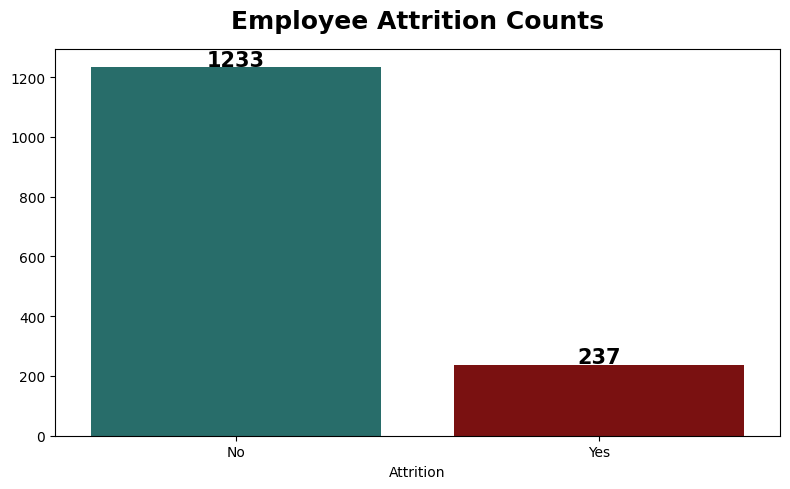

Attrition rate: 16.1% — dataset is imbalanced.


In [52]:
# Attrition distribution
plt.figure(figsize=(8, 5))
attrition_rate = df['Attrition'].value_counts()
ax = sns.barplot(x=attrition_rate.index, y=attrition_rate.values,
                 palette=['#1d7874', '#8B0000'])
plt.title('Employee Attrition Counts', fontweight='black', size=18, pad=15)
for i, v in enumerate(attrition_rate.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='black', fontsize=15)
plt.tight_layout()
plt.show()

yes_pct = (attrition_rate.get('Yes', 0) / len(df)) * 100
print(f'Attrition rate: {yes_pct:.1f}% — dataset is imbalanced.')

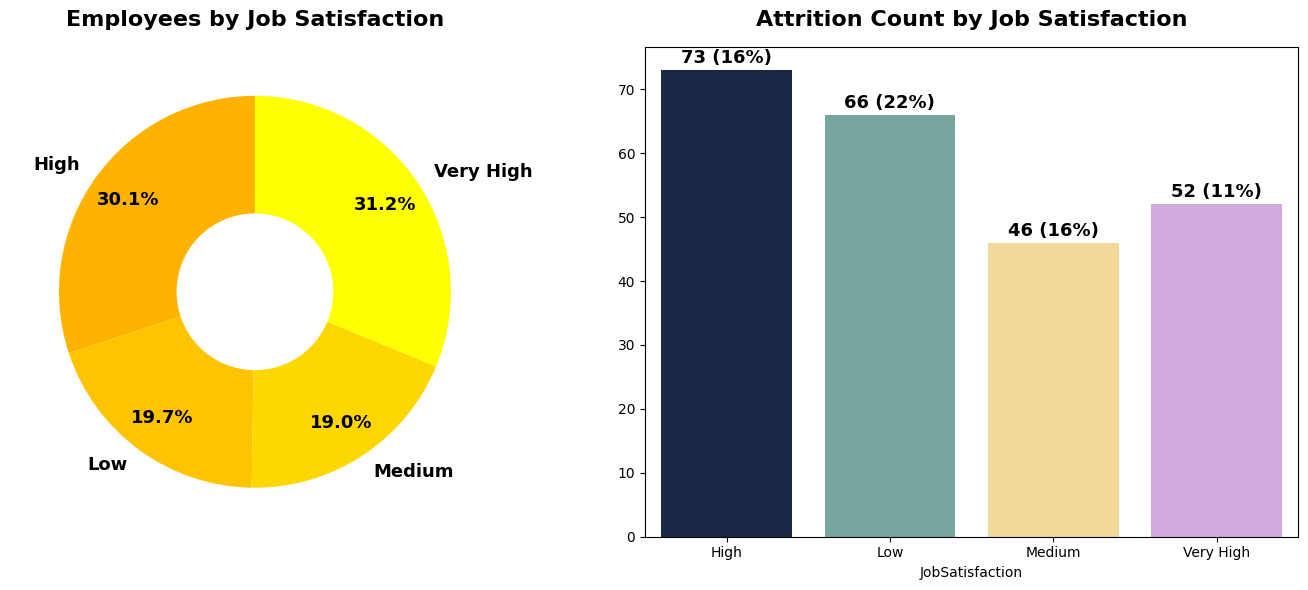

In [53]:
# Job Satisfaction analysis
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
value_1 = df['JobSatisfaction'].value_counts().sort_index()
plt.title('Employees by Job Satisfaction', fontweight='black', size=16, pad=15)
plt.pie(value_1.values, labels=value_1.index, autopct='%.1f%%', pctdistance=0.8,
        startangle=90, colors=['#FFB300', '#FFC300', '#FFD700', '#FFFF00'],
        textprops={'fontweight': 'black', 'size': 13})
center_circle = plt.Circle((0, 0), 0.4, fc='white')
plt.gca().add_artist(center_circle)

plt.subplot(1, 2, 2)
new_df = df[df['Attrition'] == 'Yes']
value_2 = new_df['JobSatisfaction'].value_counts().sort_index()
attrition_pct = np.floor((value_2.reindex(value_1.index, fill_value=0) / value_1) * 100)
ax = sns.barplot(x=value_2.index, y=value_2.values,
                 palette=['#11264e', '#6faea4', '#FEE08B', '#D4A1E7'])
plt.title('Attrition Count by Job Satisfaction', fontweight='black', size=16, pad=15)
for idx, (i, v) in enumerate(zip(value_2.index, value_2.values)):
    pct = attrition_pct.get(i, 0)
    plt.text(idx, v + 0.5, f'{v} ({int(pct)}%)', ha='center', va='bottom', size=13, fontweight='black')
plt.tight_layout()
plt.show()

1. Most of the employees have rated their job satisfaction as high or very high.
2. Employees who rated their job satisfaction low are mostly leaving the organization.
3. All the categories in job satisfaction is having high attrition rate.

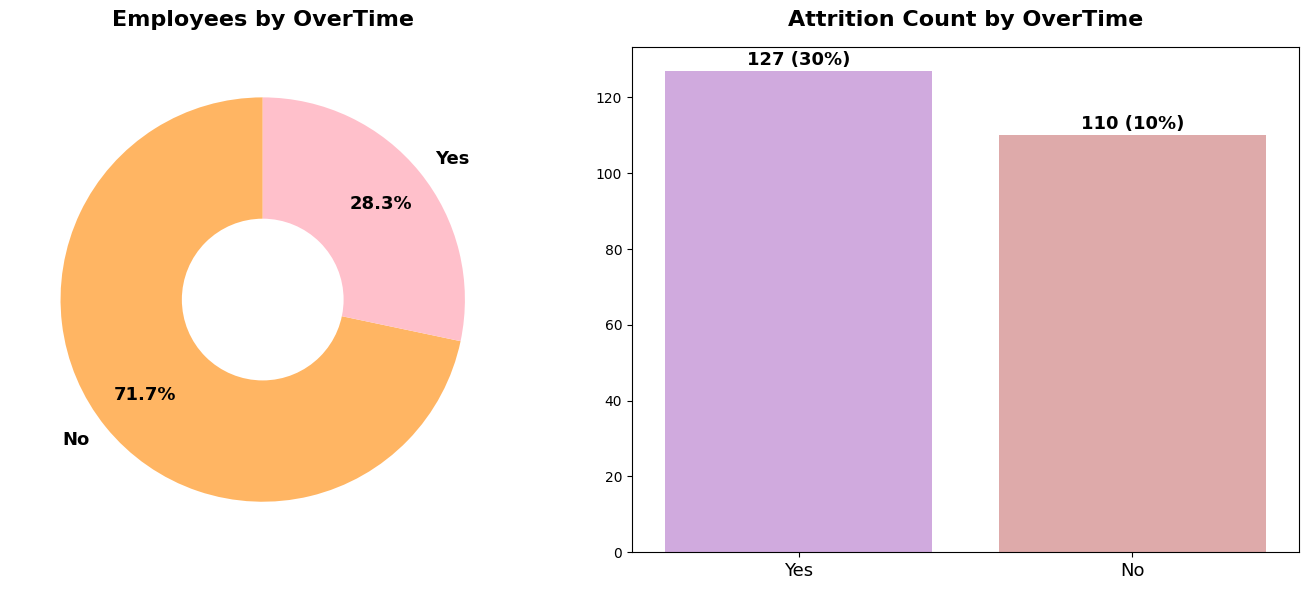

In [54]:
# OverTime analysis
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
value_1 = df['OverTime'].value_counts()
plt.title('Employees by OverTime', fontweight='black', size=16, pad=15)
plt.pie(value_1.values, labels=value_1.index, autopct='%.1f%%', pctdistance=0.75,
        startangle=90, colors=['#ffb563', '#FFC0CB'],
        textprops={'fontweight': 'black', 'size': 13})
center_circle = plt.Circle((0, 0), 0.4, fc='white')
plt.gca().add_artist(center_circle)

plt.subplot(1, 2, 2)
new_df = df[df['Attrition'] == 'Yes']
value_2 = new_df['OverTime'].value_counts()

attrition_pct = np.floor((value_2.reindex(value_1.index, fill_value=0) / value_1) * 100)
sns.barplot(x=value_2.index.tolist(), y=value_2.values, palette=['#D4A1E7', '#E7A1A1'])
plt.title('Attrition Count by OverTime', fontweight='black', size=16, pad=15)
for idx, (i, v) in enumerate(zip(value_2.index, value_2.values)):
    pct = attrition_pct.get(i, 0)
    plt.text(idx, v + 0.5, f'{v} ({int(pct)}%)', ha='center', va='bottom', size=13, fontweight='black')
plt.xticks(size=13)
plt.tight_layout()
plt.show()

1. Most of the employees doesn't work for OverTime.
2. The feature OverTime is having a very high class imbalance due to which we can't make any meaningful insights.

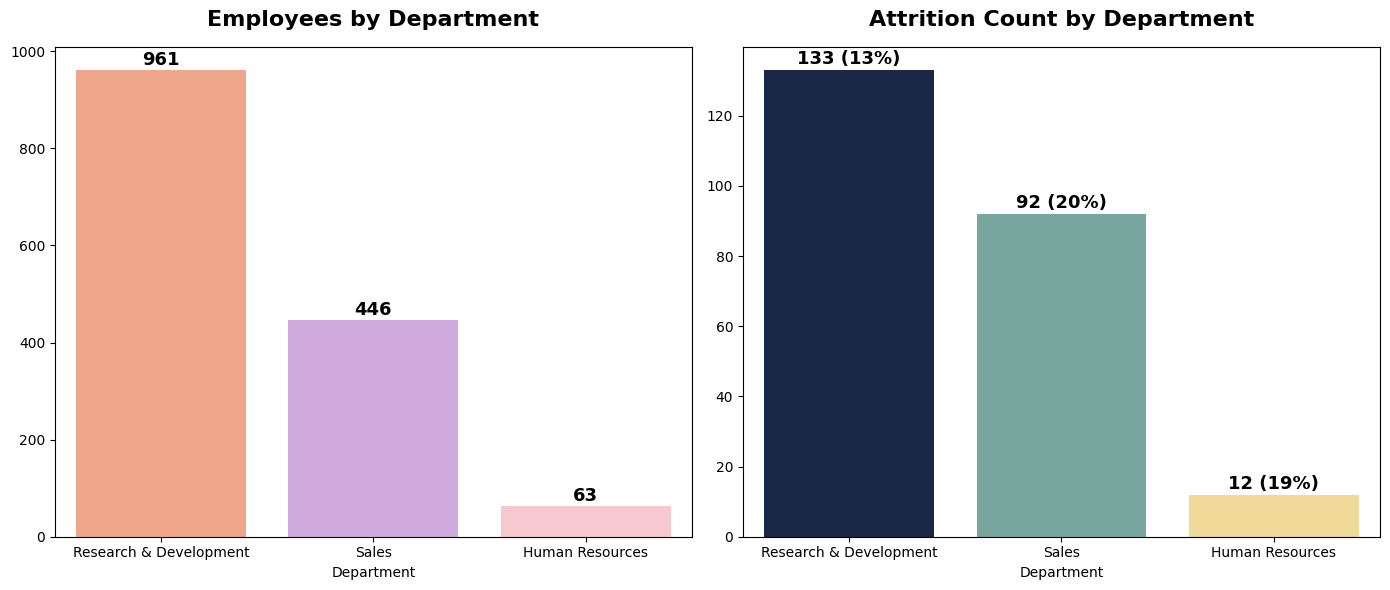

In [55]:
# Department analysis
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
value_1 = df['Department'].value_counts()
sns.barplot(x=value_1.index, y=value_1.values, palette=['#FFA07A', '#D4A1E7', '#FFC0CB'])
plt.title('Employees by Department', fontweight='black', size=16, pad=15)
for index, value in enumerate(value_1.values):
    plt.text(index, value + 2, value, ha='center', va='bottom', fontweight='black', size=13)

plt.subplot(1, 2, 2)
new_df = df[df['Attrition'] == 'Yes']
value_2 = new_df['Department'].value_counts()

attrition_pct = np.floor((value_2.reindex(value_1.index, fill_value=0) / value_1) * 100)
sns.barplot(x=value_2.index, y=value_2.values, palette=['#11264e', '#6faea4', '#FEE08B'])
plt.title('Attrition Count by Department', fontweight='black', size=16, pad=15)
for idx, (i, v) in enumerate(zip(value_2.index, value_2.values)):
    pct = attrition_pct.get(i, 0)
    plt.text(idx, v + 0.5, f'{v} ({int(pct)}%)', ha='center', va='bottom', size=13, fontweight='black')
plt.tight_layout()
plt.show()

1. Most of the employees are from Research & Development Department.
2. Highest Attrition is in the Sales Department.
3. Human Resources Department Attrition rate is also very high.
4. Though of highest employees in Research & Development department there is least attrition compared to other departments.

## Feature Engineering

In [56]:
label_encoders = {}
categorical_cols = ['Attrition', 'OverTime', 'Department']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # ✅ Save each encoder for future inverse_transform

print('Encoding complete. Attrition mapping:', dict(zip(label_encoders['Attrition'].classes_,
                                                        label_encoders['Attrition'].transform(label_encoders['Attrition'].classes_))))

Encoding complete. Attrition mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


In [57]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# One-hot encode any remaining categoricals
X = pd.get_dummies(X)

# Scale (required for chi2 which needs non-negative values)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#  Store feature names BEFORE SelectKBest so we can recover them later
feature_names = list(X.columns)

# Chi-squared feature selection
chi_selector = SelectKBest(chi2, k=10)
X_chi = chi_selector.fit_transform(X_scaled, y)
chi_features = [feature_names[i] for i in chi_selector.get_support(indices=True)]
print('Chi2 selected features:', chi_features)

# ANOVA feature selection
anova_selector = SelectKBest(f_classif, k=10)
X_anova = anova_selector.fit_transform(X_scaled, y)
anova_features = [feature_names[i] for i in anova_selector.get_support(indices=True)]
print('ANOVA selected features:', anova_features)

# Use full scaled feature set for model training (more data = better model)
# SelectKBest outputs are shown for analysis only
X_final = X_scaled

Chi2 selected features: ['OverTime', 'BusinessTravel_Travel_Frequently', 'EnvironmentSatisfaction_Low', 'JobInvolvement_Low', 'JobLevel_Entry Level', 'JobLevel_Junior Level', 'JobRole_Laboratory Technician', 'JobRole_Sales Representative', 'MaritalStatus_Single', 'WorkLifeBalance_Bad']
ANOVA selected features: ['Age', 'MonthlyIncome', 'OverTime', 'StockOptionLevel', 'TotalWorkingYears', 'YearsInCurrentRole', 'YearsWithCurrManager', 'JobLevel_Entry Level', 'JobRole_Sales Representative', 'MaritalStatus_Single']


## Model Building

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y 
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train attrition rate: {y_train.mean():.3f} | Test: {y_test.mean():.3f}')

Train: (1176, 72), Test: (294, 72)
Train attrition rate: 0.162 | Test: 0.160


In [59]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')  # ✅ class_weight handles imbalance
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [60]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=6, class_weight='balanced')
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [ ]:
# XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale = neg_count / pos_count

xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale,  
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Model Evaluation


=== Logistic Regression (Accuracy: 0.8163) ===
              precision    recall  f1-score   support

No Attrition       0.94      0.83      0.88       247
   Attrition       0.45      0.72      0.56        47

    accuracy                           0.82       294
   macro avg       0.70      0.78      0.72       294
weighted avg       0.86      0.82      0.83       294


=== Decision Tree (Accuracy: 0.7823) ===
              precision    recall  f1-score   support

No Attrition       0.91      0.83      0.86       247
   Attrition       0.38      0.55      0.45        47

    accuracy                           0.78       294
   macro avg       0.64      0.69      0.66       294
weighted avg       0.82      0.78      0.80       294


=== XGBoost (Accuracy: 0.8469) ===
              precision    recall  f1-score   support

No Attrition       0.87      0.96      0.91       247
   Attrition       0.55      0.26      0.35        47

    accuracy                           0.85       294
  

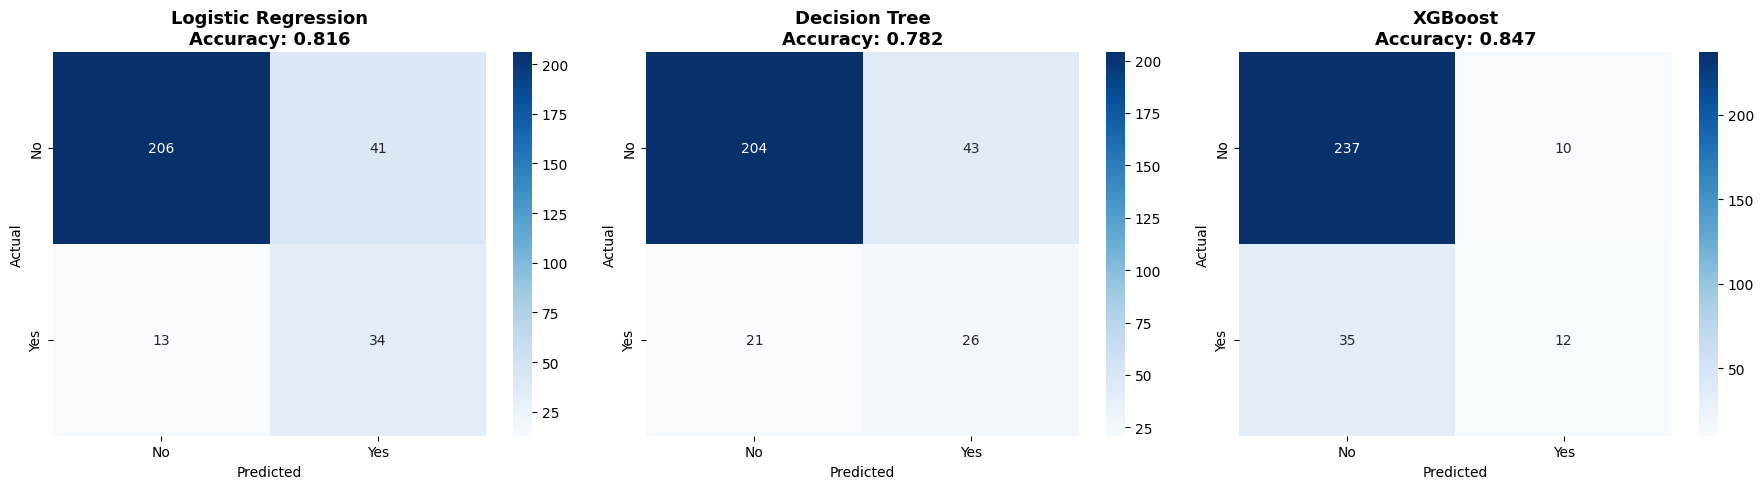

In [ ]:
models = {'Logistic Regression': lr, 'Decision Tree': dt, 'XGBoost': xgb}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f'\n=== {name} (Accuracy: {acc:.4f}) ===')
    print(classification_report(y_test, pred, target_names=['No Attrition', 'Attrition']))

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}', fontweight='black', size=13)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## SHAP

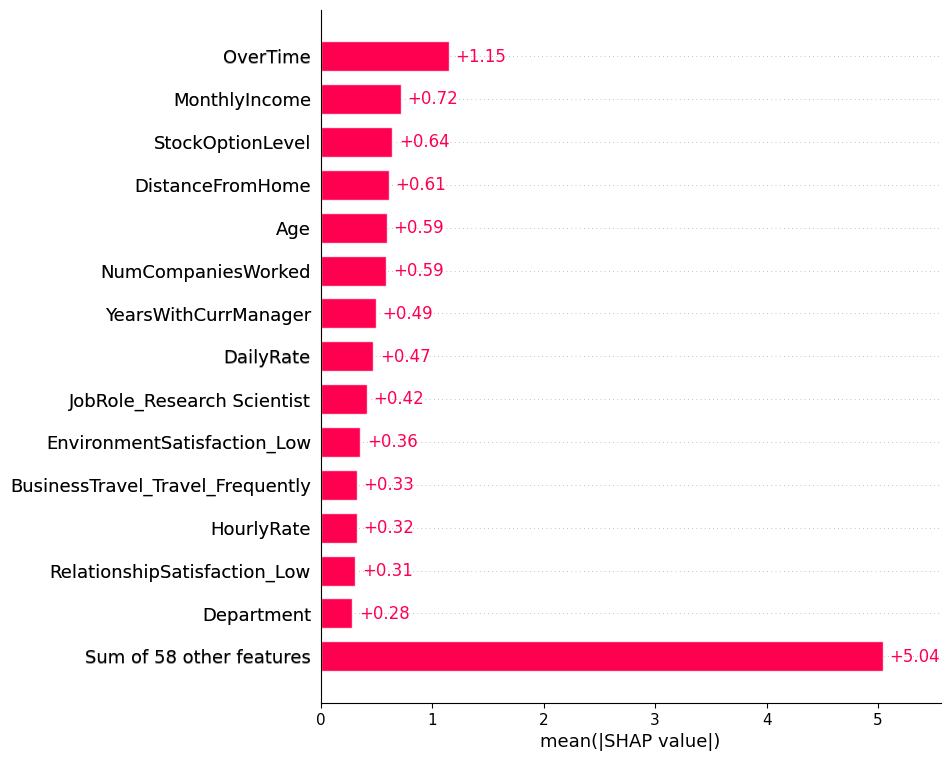

In [69]:
import shap

explainer = shap.Explainer(xgb, feature_names=feature_names)
shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=15)

"Overtime" is the most important feature

In [ ]:
best_model = xgb  

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('columns.pkl', 'wb') as f:
    pickle.dump(feature_names, f)  

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)         

print('Model, columns, and scaler saved successfully ✅')

Model, columns, and scaler saved successfully ✅
